pip install prophet

In [2]:
from prophet import Prophet

# Phase 1: Data Preparation

In [5]:
import xarray as xr

# Open NetCDF file
dataset = xr.open_dataset('preprocessed_merged_dataset.nc')

# View data structure
print(dataset)

# View all variables
print(dataset.data_vars)


<xarray.Dataset> Size: 72MB
Dimensions:     (time: 27374, lat: 11, lon: 6)
Coordinates:
  * lat         (lat) float32 44B 49.48 50.42 51.36 52.3 ... 57.02 57.96 58.9
  * lon         (lon) float32 24B 352.5 353.8 355.0 356.2 357.5 358.8
  * time        (time) datetime64[ns] 219kB 2006-01-02 2006-01-03 ... 2080-12-12
Data variables:
    TREFMXAV_U  (time, lat, lon) float64 14MB ...
    FLNS        (time, lat, lon) float32 7MB ...
    FSNS        (time, lat, lon) float32 7MB ...
    PRECT       (time, lat, lon) float32 7MB ...
    PRSN        (time, lat, lon) float32 7MB ...
    QBOT        (time, lat, lon) float32 7MB ...
    TREFHT      (time, lat, lon) float32 7MB ...
    UBOT        (time, lat, lon) float32 7MB ...
    VBOT        (time, lat, lon) float32 7MB ...
Data variables:
    TREFMXAV_U  (time, lat, lon) float64 14MB ...
    FLNS        (time, lat, lon) float32 7MB ...
    FSNS        (time, lat, lon) float32 7MB ...
    PRECT       (time, lat, lon) float32 7MB ...
    PRSN    

In [7]:
#Step 2️⃣ Extract TREFHT + spatial average
trefht_mean = dataset['TREFHT'].mean(dim=['lat', 'lon'])
#Step 3️⃣ Convert to pandas DataFrame
df = trefht_mean.to_dataframe().reset_index()
#Step 4️⃣ Processing time and column names
df_prophet = df.rename(columns={'time': 'ds', 'TREFHT': 'y'})
df

,time,TREFHT
0,2006-01-02,7.633643
1,2006-01-03,8.140079
2,2006-01-04,7.396738
3,2006-01-05,7.108317
4,2006-01-06,7.409958
...,...,...
27369,2080-12-08,8.972991
27370,2080-12-09,9.551692
27371,2080-12-10,9.197808
27372,2080-12-11,8.545174


# Phase 2: Model Development

In [12]:
#Step 5️⃣ Initialize the Prophet model
from prophet import Prophet
model = Prophet()

#Step 6️⃣ Train the model (historical data 2006 - 2024)
model.fit(df_prophet[df_prophet['ds'].dt.year <= 2025])

#Step 7️⃣ Create future forecasts - date forecasts 2025-2080
future = model.make_future_dataframe(periods=2080-2024, freq='YE')

#Step 8️⃣ Predict and generate results
forecast = model.predict(future)


10:53:38 - cmdstanpy - INFO - Chain [1] start processing
10:53:38 - cmdstanpy - INFO - Chain [1] done processing


Phase 3: Results Analysis

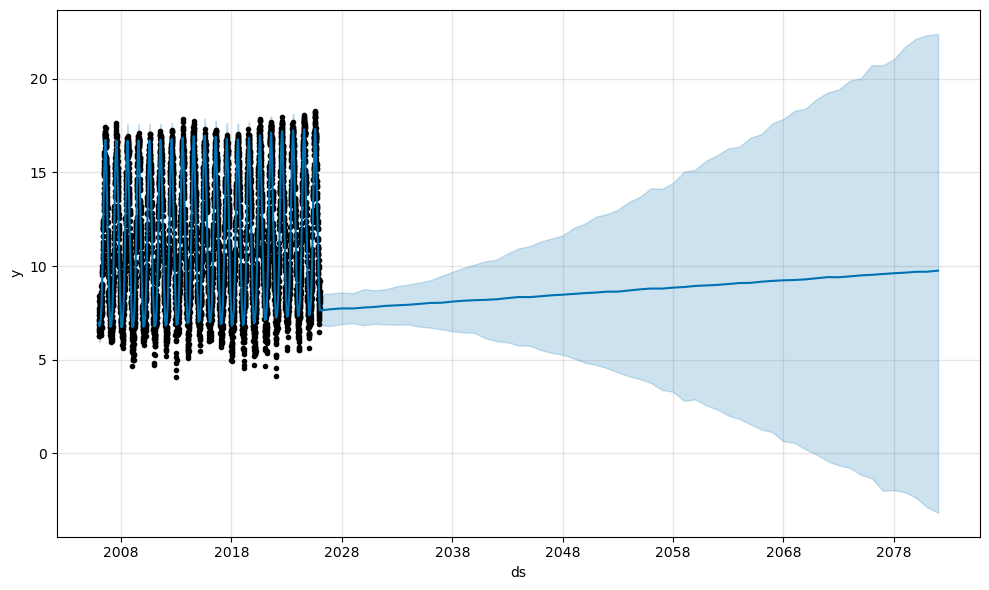

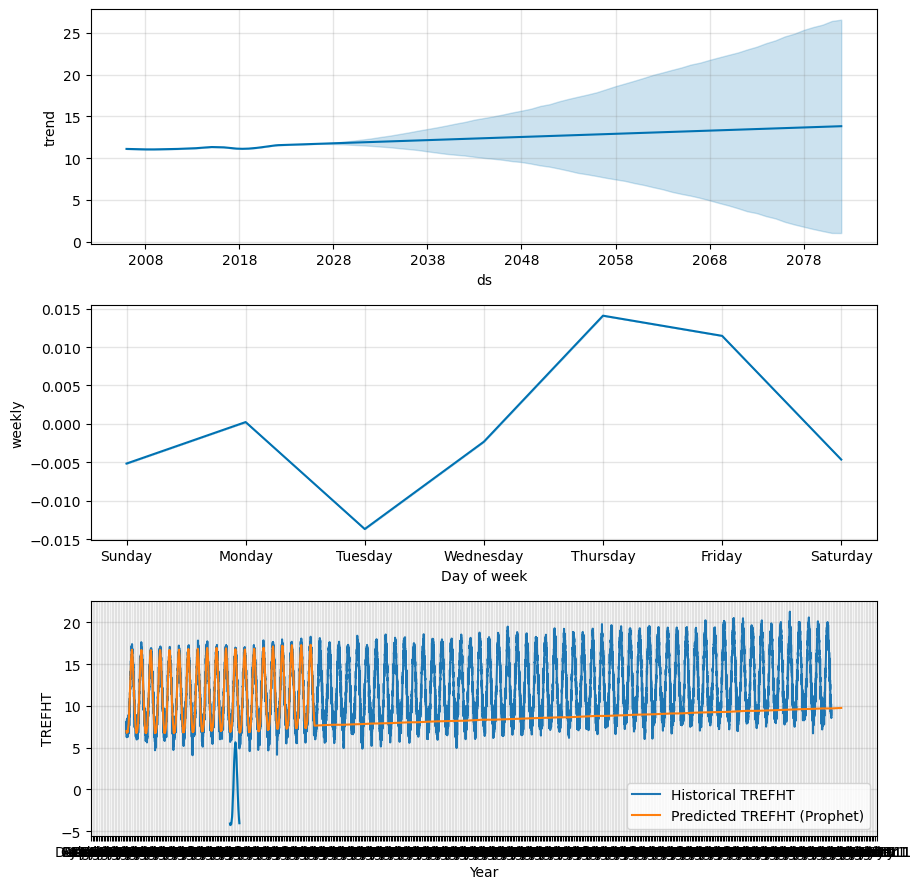

In [14]:
#Step 9️⃣ Visualize the overall trend
fig1 = model.plot(forecast)
#Step 🔟 Trend component analysis
fig2 = model.plot_components(forecast)
#Step 1️⃣ 1️⃣ Customize trend chart
import matplotlib.pyplot as plt

plt.plot(df_prophet['ds'], df_prophet['y'], label='Historical TREFHT')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted TREFHT (Prophet)')
plt.xlabel('Year')
plt.ylabel('TREFHT')
plt.legend()
plt.show()


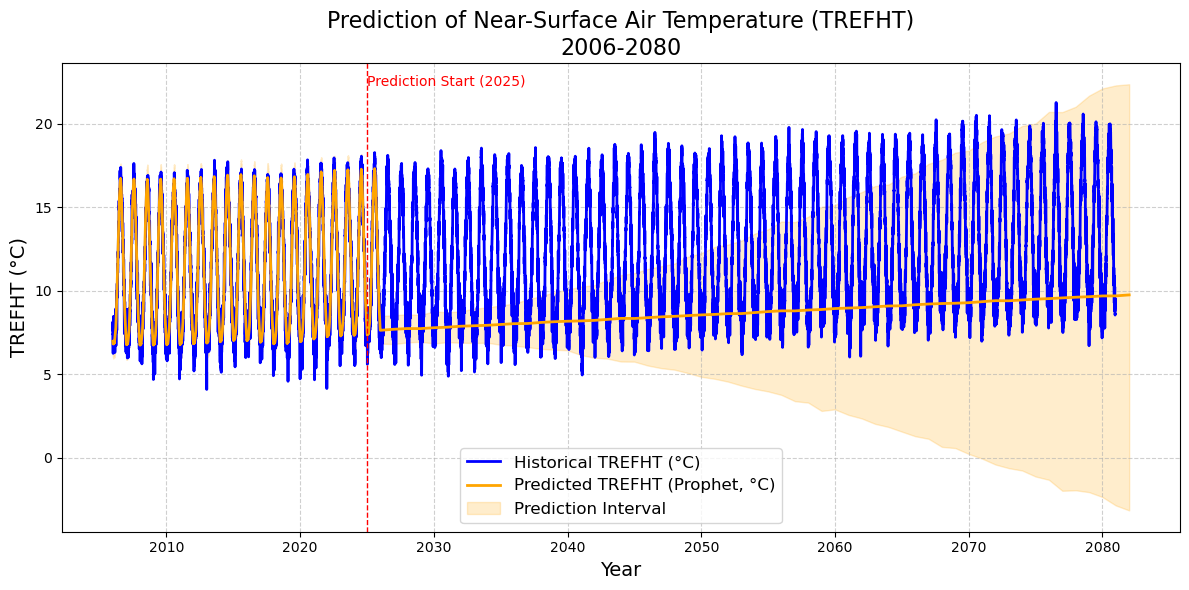

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Historical data (2006-2014)
plt.plot(df_prophet['ds'], df_prophet['y'], 
         label='Historical TREFHT (°C)', 
         color='blue', linewidth=2)

# Forecast data (2015-2080)
plt.plot(forecast['ds'], forecast['yhat'], 
         label='Predicted TREFHT (Prophet, °C)', 
         color='orange', linewidth=2)

# Confidence interval
plt.fill_between(forecast['ds'], 
                 forecast['yhat_lower'], 
                 forecast['yhat_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')

# Prediction starting point identification line (2016)
plt.axvline(x=pd.to_datetime('2024-12-31'), color='red', linestyle='--', linewidth=1)
plt.text(pd.to_datetime('2025-01-01'), max(df_prophet['y'])+1, 
         'Prediction Start (2025)', color='red')

# Title & axis labels
plt.title('Prediction of Near-Surface Air Temperature (TREFHT)\n2006-2080', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('TREFHT (°C)', fontsize=14)

# Grid & Legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Optimize layout
plt.tight_layout()
plt.show()


## 🔵 Blue line (historical data: 2006-2024)
Shows clear periodicity (intra-year fluctuations)

Peaks and troughs are very obvious

This is the real observation data (or high-confidence data) provided by your team members

🟠 Orange line (Prophet model prediction: 2025-2080)
The trend is too stable
👉 Only captures the "trend" and does not consider the annual periodicity (seasonality disappears)
👉 Prophet will not automatically turn on yearly seasonality by default (unless you enable it)

The predicted value is almost a straight line
👉 This shows that the model judges that the temperature is rising slowly and the long-term growth trend is weak

🟡 Light orange shadow (prediction interval, uncertainty)
The uncertainty increases as time goes on

The shadow interval is from 0°C to 25°C, and the confidence interval in the next few decades is ridiculously wide
👉 This is the uncertainty problem of the Prophet model in long-term prediction

Summary of model prediction problems
Seasonal fluctuations are lost
👉 Not enabled yearly_seasonality

The trend is too stable
👉 You are using the default linear growth mode of Prophet
👉 You can consider logistic growth, or directly change the model (such as XGBoost, LSTM)

# Optimized Prophet model

In [26]:
from prophet import Prophet

# Initialize the model, enable annual seasonality (manually added), multiplicative seasonality, and trend change sensitivity
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # More suitable for scenarios where the temperature increases with the trend and the cycle amplitude becomes larger
    changepoint_prior_scale=0.05          # Trend changes are more sensitive
)

# Manually add annual periodicity and increase the Fourier order (more complex periodic patterns)
model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=20  # or 30, the larger the value, the finer the fitting of period fluctuations
)

# Train the model (using real data from 2006-2015)
train_df = df_prophet[df_prophet['ds'].dt.year <= 2015]
model.fit(train_df)


18:02:34 - cmdstanpy - INFO - Chain [1] start processing
18:02:34 - cmdstanpy - INFO - Chain [1] done processing


Generate future forecast data (2025-2080)

In [94]:
# Set the prediction time range
years_to_predict = 2080 - 2025  # 55 years

# Day granularity prediction
periods = years_to_predict * 365 

# Generate future time (including training set)
future = model.make_future_dataframe(periods=periods, freq='D')

# Make predictions
forecast = model.predict(future)

# Verify the forecast time range
print(forecast['ds'].min(), forecast['ds'].max())


2006-01-02 00:00:00 2080-12-15 00:00:00


# Visualizing historical and forecast results (professional presentation)

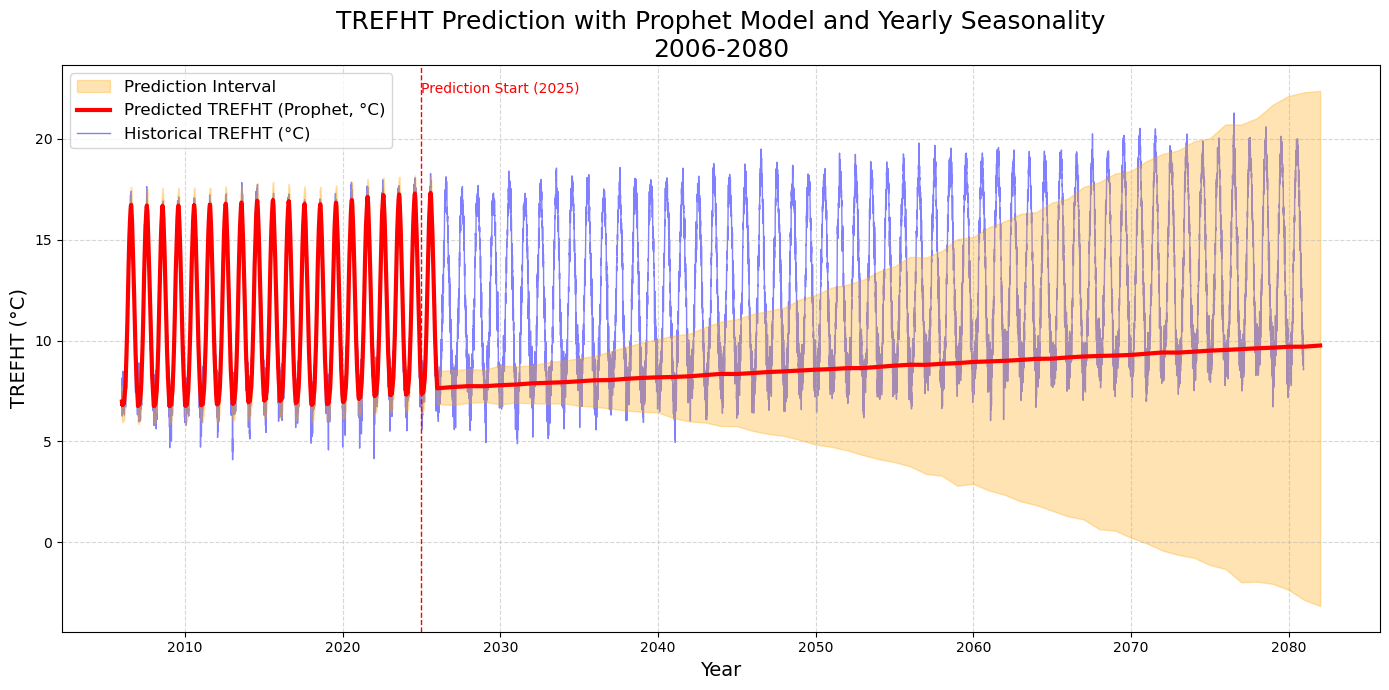

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Draw the Prediction Interval (confidence interval)
plt.fill_between(forecast['ds'],
                 forecast['yhat_lower'],
                 forecast['yhat_upper'],
                 color='orange',
                 alpha=0.3,
                 label='Prediction Interval',
                 zorder=1)

# Plotting Predicted TREFHT
plt.plot(forecast['ds'],
         forecast['yhat'],
         label='Predicted TREFHT (Prophet, °C)',
         color='red',
         linewidth=3,
         zorder=2)

# Plotting Historical TREFHT
plt.plot(df_prophet['ds'],
         df_prophet['y'],
         label='Historical TREFHT (°C)',
         color='blue',
         linewidth=1,
         alpha=0.5,
         zorder=0)

# Predict starting line
plt.axvline(x=pd.to_datetime('2024-12-31'),
            color='red', linestyle='--', linewidth=1)
plt.text(pd.to_datetime('2025-01-01'),
         df_prophet['y'].max() + 1,
         'Prediction Start (2025)',
         color='red', fontsize=10)

# Chart information
plt.title('TREFHT Prediction with Prophet Model and Yearly Seasonality\n2006-2080', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('TREFHT (°C)', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Cross Validation

  0%|          | 0/19 [00:00<?, ?it/s]

10:59:14 - cmdstanpy - INFO - Chain [1] start processing
10:59:15 - cmdstanpy - INFO - Chain [1] done processing
10:59:15 - cmdstanpy - INFO - Chain [1] start processing
10:59:15 - cmdstanpy - INFO - Chain [1] done processing
10:59:15 - cmdstanpy - INFO - Chain [1] start processing
10:59:15 - cmdstanpy - INFO - Chain [1] done processing
10:59:15 - cmdstanpy - INFO - Chain [1] start processing
10:59:16 - cmdstanpy - INFO - Chain [1] done processing
10:59:16 - cmdstanpy - INFO - Chain [1] start processing
10:59:16 - cmdstanpy - INFO - Chain [1] done processing
10:59:16 - cmdstanpy - INFO - Chain [1] start processing
10:59:16 - cmdstanpy - INFO - Chain [1] done processing
10:59:17 - cmdstanpy - INFO - Chain [1] start processing
10:59:17 - cmdstanpy - INFO - Chain [1] done processing
10:59:17 - cmdstanpy - INFO - Chain [1] start processing
10:59:17 - cmdstanpy - INFO - Chain [1] done processing
10:59:17 - cmdstanpy - INFO - Chain [1] start processing
10:59:18 - cmdstanpy - INFO - Chain [1]

  horizon       mse      rmse       mae      mape     mdape     smape  \
0 37 days  0.496508  0.704633  0.550406  0.065685  0.036664  0.063978   
1 38 days  0.496716  0.704781  0.549024  0.065580  0.035700  0.063811   
2 39 days  0.498196  0.705830  0.548170  0.065666  0.035593  0.063824   
3 40 days  0.497915  0.705631  0.546296  0.065508  0.035593  0.063628   
4 41 days  0.492887  0.702059  0.543277  0.064794  0.036378  0.063010   

   coverage  
0  0.790157  
1  0.790157  
2  0.790917  
3  0.793879  
4  0.796689  


/opt/anaconda3/lib/python3.10/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/opt/anaconda3/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


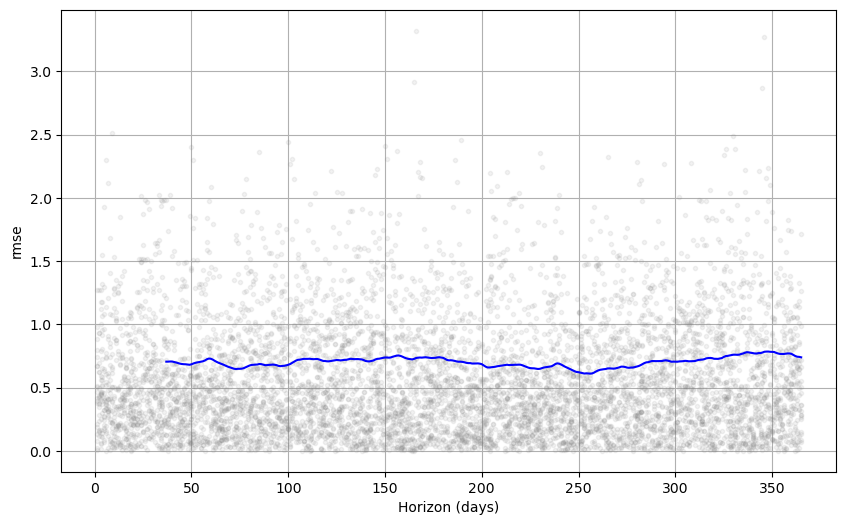

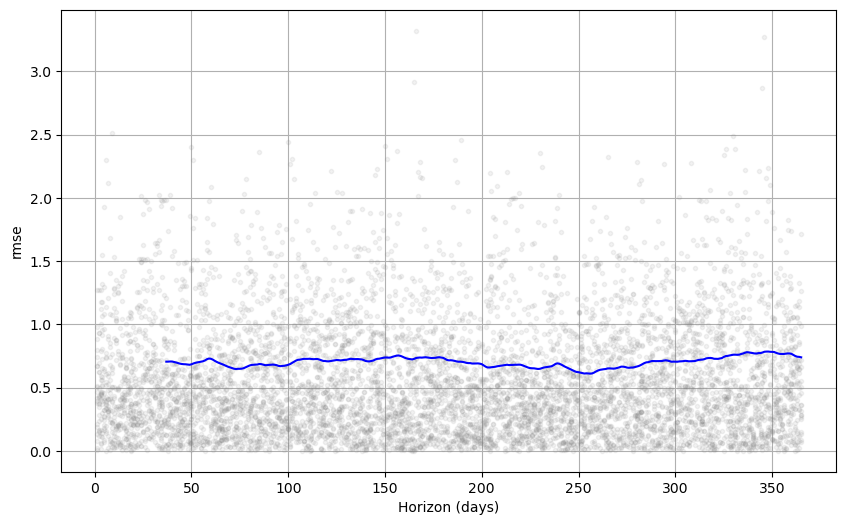

In [29]:
from prophet.diagnostics import cross_validation, performance_metrics

# Perform cross validation:
# - initial: length of training set (e.g. '3650 days' = 10 years)
# - period: interval of each sliding window (e.g. '180 days')
# - horizon: how far to predict (e.g. '365 days')

df_cv = cross_validation(
    model,
    initial='3650 days',   # Use first 10 years for training
    period='180 days',     # Slide every 180 days
    horizon='365 days'    # Each prediction is 1 year
)

# Check the prediction performance
df_p = performance_metrics(df_cv)
print(df_p.head())


from prophet.plot import plot_cross_validation_metric
plot_cross_validation_metric(df_cv, metric='rmse')


# Summary

Overall, your Prophet model performs well in the temperature time series forecasting task, especially:

RMSE is stable at around 0.7

MAPE is low (<7%), which is an excellent level

The error does not increase significantly as the horizon increases → The model generalizes well